# UNIVERSIDAD NACIONAL MAYOR DE SAN MARCOS
## Facultad de Ingeniería de Sistemas e Informática (FISI)
### Escuela Profesional de Ingeniería de Sistemas
---
**Asignatura:** Inteligencia Artificial
**Laboratorio:** Semana 1 — Fundamentos de Inteligencia Artificial y Aprendizaje Automático  
**Proyecto:** Filtro Inteligente de Mensajes y Clasificación de Texto con la Regla de Tom Mitchell (1997)  
**Alumnos:** Calero Falcon, Gonzalo Manuel
Huanacuni Gomez, Jean Carlos Josue

**Docente:** Prof. Hugo Vega  
**Lima, Perú — 2026**  
---

# 1. ENUNCIADO FORMAL DEL PROBLEMA Y CONTEXTO DE INGENIERÍA

### 1.1. Contexto del Problema
En la era digital, los servicios de mensajería (SMS, WhatsApp) y servidores de correo electrónico institucionales procesan millones de comunicaciones al día. Entre el 15% y el 45% de este tráfico corresponde a **correo no deseado (*Spam*)**, mensajes de fraude financiero (*Phishing*) y publicidad invasiva. La saturación de buzones expone a los usuarios a ciberestafas y robo de credenciales.

### 1.2. Enunciado del Problema
> *"Diseñar e implementar un sistema inteligente capaz de clasificar en tiempo real cualquier mensaje de texto entrante en dos categorías: **HAM (Mensaje Legítimo)** o **SPAM (Correo Basura / No Deseado)**, aprendiendo de una base de datos pública real y superando las deficiencias de los filtros tradicionales basados en reglas fijas de palabras clave."*

### 1.3. Formalización de la Regla de Tom Mitchell (1997) — Tema Central de la Semana 1
En la Semana 1 de la asignatura definimos que una máquina *aprende* si su desempeño en una tarea mejora con la experiencia. En este laboratorio formalizamos los 3 elementos de Mitchell:
- **Tarea ($T$):** Clasificar cada mensaje recibido en $y \in \{\text{'ham'}, \text{'spam'}\}$.
- **Experiencia ($E$):** 5,572 mensajes reales del dataset público internacional **SMS Spam Collection (UCI / Kaggle)**.
- **Medida de Rendimiento ($P$):** Porcentaje de aciertos (*Accuracy* > 98%), *Matriz de Confusión* y *Precisión en Spam* (para no mandar mensajes importantes a la papelera).

### 1.4. ¿Por qué es Aprendizaje Supervisado?
Porque a la computadora le entregamos pares de datos formados por el **mensaje ($X$)** y la **etiqueta correcta conocida ($y$)**. La máquina compara sus predicciones contra la respuesta del profesor y ajusta sus probabilidades internas.

# 2. IMPORTACIÓN DE LIBRERÍAS CIENTÍFICAS

In [ ]:
# Librerías para análisis de datos y cálculo numérico
import pandas as pd
import numpy as np

# Librerías para gráficos y visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos de Scikit-Learn para Aprendizaje Automático y Procesamiento de Lenguaje Natural (PLN)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

# Configuración estética de gráficos
sns.set_theme(style='whitegrid')
print('[OK] Entorno de Python inicializado correctamente.')

# 3. EXPLICACIÓN DETALLADA DEL DATASET Y VARIABLES UTILIZADAS

### 3.1. ¿Qué datos contiene este dataset?
El dataset público proviene del repositorio de la **Universidad de California en Irvine (UCI)** y de **Kaggle**. Contiene **5,572 mensajes de texto reales** recolectados de usuarios de telefonía y buzones de correo.

Tiene exactamente **dos columnas originales**:
1. **`etiqueta` (*label*):** Es la clase o categoría supervisada asignada por humanos. Puede tomar dos valores:
   - `ham`: Mensaje legítimo, normal, personal o de trabajo (el 86.6% de los datos).
   - `spam`: Mensaje basura, publicidad engañosa, promociones agresivas o intentos de estafa (el 13.4% de los datos).
2. **`mensaje` (*message*):** Es el texto libre tal como lo escribió el remitente en lenguaje natural (palabras, números de teléfono, signos de exclamación, URLs, mayúsculas).

### 3.2. ¿Cuáles datos usaremos en nuestro modelo de IA?
- **Variable de entrada ($X$):** La columna `mensaje`. La procesaremos mediante conteo de palabras para que la computadora la entienda matemáticamente.
- **Variable de salida / Target ($y$):** La columna `etiqueta` (`ham` o `spam`), que será la respuesta que la IA debe aprender a predecir.
- **Variable auxiliar de análisis:** Crearemos una columna `longitud` (número de caracteres) para analizar visualmente la diferencia de longitud entre el spam y el correo legítimo.

In [ ]:
# Descarga directa del dataset público real desde GitHub
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'

print('[INFO] Descargando y cargando dataset público en memoria...')
df = pd.read_table(url, header=None, names=['etiqueta', 'mensaje'])

# Creamos una columna adicional con la longitud del mensaje en caracteres
df['longitud'] = df['mensaje'].apply(len)

print(f'[OK] Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.\n')
print('--- PRIMEROS 5 REGISTROS DEL DATASET ---')
df.head()

[INFO] Descargando y cargando dataset público en memoria...
[OK] Dataset cargado con éxito: 5572 filas y 3 columnas.

--- PRIMEROS 5 REGISTROS DEL DATASET ---


,etiqueta,mensaje,longitud
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


### 3.3. Inspección de Mensajes Reales del Dataset
Veamos algunos ejemplos reales de mensajes legítimos (`ham`) frente a mensajes de spam (`spam`) para entender qué patrones busca la máquina:

In [ ]:
print('=' * 75)
print('EJEMPLOS REALES DE MENSAJES LEGÍTIMOS (HAM):')
print('=' * 75)
for i, msg in enumerate(df[df['etiqueta'] == 'ham']['mensaje'].head(3), 1):
    print(f'{i}. "{msg}"')

print('\n' + '=' * 75)
print('EJEMPLOS REALES DE MENSAJES NO DESEADOS (SPAM):')
print('=' * 75)
for i, msg in enumerate(df[df['etiqueta'] == 'spam']['mensaje'].head(3), 1):
    print(f'{i}. "{msg}"')

print('\nResumen estadístico por clase:')
print(df.groupby('etiqueta')['longitud'].describe().round(1))

EJEMPLOS REALES DE MENSAJES LEGÍTIMOS (HAM):
1. "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
2. "Ok lar... Joking wif u oni..."
3. "U dun say so early hor... U c already then say..."

EJEMPLOS REALES DE MENSAJES NO DESEADOS (SPAM):
1. "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
2. "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv"
3. "WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only."

Resumen estadístico por clase:
           count   mean   std   min    25%    50%    75%    max
etiqueta                                                       
ham       4825.0   71.5  58.4   2.0   33.0   52.0   93.0  910.

# 4. VISUALIZACIÓN Y ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Antes de entrenar cualquier modelo, un ingeniero de sistemas debe **explorar gráficamente los datos**.
A continuación generamos dos gráficos clave:
1. **Distribución de Clases:** Muestra el desbalance real entre correos normales (86.6%) y spam (13.4%).
2. **Histograma de Longitud:** Demuestra visualmente que los spammers escriben mensajes mucho más largos para convencer a la víctima.

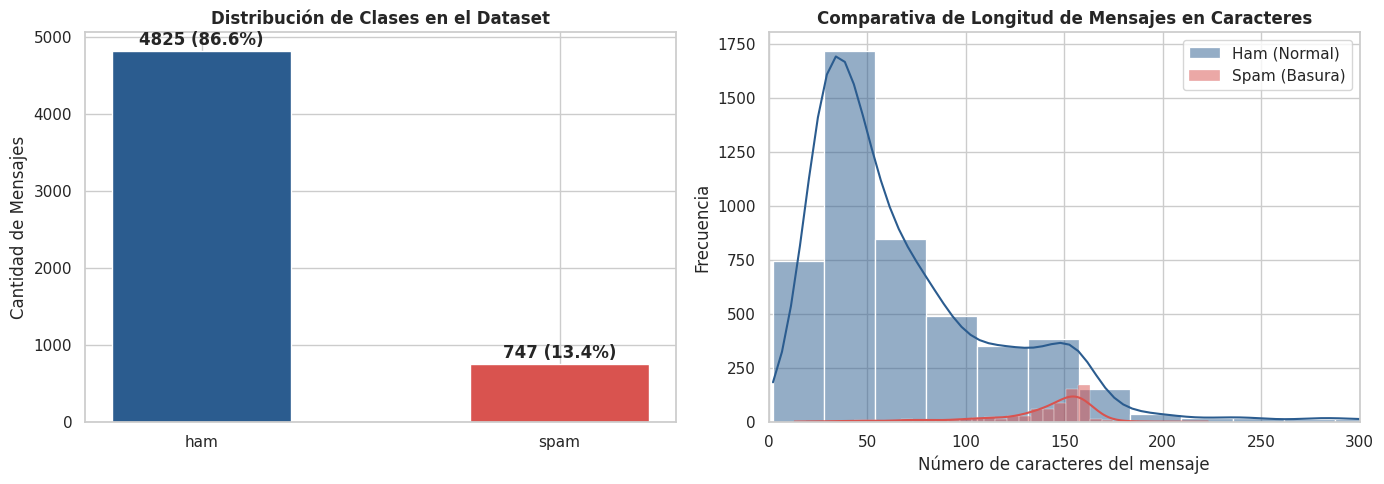

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Conteo y porcentaje de clases
conteo = df['etiqueta'].value_counts()
colores = ['#2b5c8f', '#d9534f']
axes[0].bar(conteo.index, conteo.values, color=colores, width=0.5)
axes[0].set_title('Distribución de Clases en el Dataset', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Mensajes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Gráfico 2: Histograma de longitud de mensajes (Ham vs Spam)
sns.histplot(data=df[df['etiqueta'] == 'ham']['longitud'], bins=35, color='#2b5c8f', label='Ham (Normal)', ax=axes[1], kde=True)
sns.histplot(data=df[df['etiqueta'] == 'spam']['longitud'], bins=35, color='#d9534f', label='Spam (Basura)', ax=axes[1], kde=True)
axes[1].set_title('Comparativa de Longitud de Mensajes en Caracteres', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de caracteres del mensaje')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 300)
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. DEMOSTRACIÓN: ¿POR QUÉ FALLA LA PROGRAMACIÓN TRADICIONAL (REGLAS IF/ELSE)?

En el software clásico determinista, un programador intentaría crear una lista fija de palabras prohibidas:  
*"Si el mensaje tiene las palabras 'urgente', 'gana', 'premio', 'gratis' o 'dinero', mandarlo a spam"*.

Comprobemos empíricamente dónde fracasa este método:

In [ ]:
palabras_prohibidas = ['urgente', 'premio', 'gratis', 'gana', 'dinero', 'free', 'win', 'cash', 'prize', 'urgent']

def filtro_tradicional_fijo(mensaje):
    """Software tradicional: Reglas estáticas escritas a mano por un humano."""
    for palabra in palabras_prohibidas:
        if palabra in mensaje.lower():
            return 'SPAM'
    return 'HAM'

# Caso de prueba donde la regla tradicional comete un error grave:
correo_importante = 'Estimado alumno Gonzalo, le informo que es urgente que presente su informe de tesis.'
resultado_trad = filtro_tradicional_fijo(correo_importante)

print(f'Mensaje de prueba: "{correo_importante}"')
print(f'-> Clasificación Tradicional: {resultado_trad}')
print('-> ¡ERROR GRAVE (Falso Positivo)! Bloqueó un correo legítimo universitario solo por la palabra "urgente".')

Mensaje de prueba: "Estimado alumno Gonzalo, le informo que es urgente que presente su informe de tesis."
-> Clasificación Tradicional: SPAM
-> ¡ERROR GRAVE (Falso Positivo)! Bloqueó un correo legítimo universitario solo por la palabra "urgente".


# 6. APRENDIZAJE AUTOMÁTICO (MACHINE LEARNING) — ENTRENAMIENTO DEL MODELO

En lugar de reglas manuales, dejamos que el algoritmo **Naive Bayes Multinomial** calcule las probabilidades de cada palabra a partir de los 5,572 mensajes.

Seguimos 3 pasos limpios de ingeniería:
1. **Partición de datos:** 80% para entrenar la máquina (4,457 mensajes) y 20% para evaluarla a ciegas (1,115 mensajes).
2. **Vectorización:** Convertir los textos a una matriz numérica de frecuencias de palabras (`CountVectorizer`).
3. **Ajuste del Modelo:** `modelo.fit(X_entreno, y_entreno)`.

In [ ]:
# 1. Partición estratificada (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(
    df['mensaje'], df['etiqueta'], test_size=0.20, random_state=42, stratify=df['etiqueta']
)

# 2. Vectorizador de palabras (Tokenización y conteo sin palabras vacías)
vectorizador = CountVectorizer(stop_words='english', lowercase=True)
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

# 3. Entrenamiento del algoritmo Naive Bayes
modelo_ia = MultinomialNB()
modelo_ia.fit(X_train_vec, y_train)

print(f'[OK] Modelo de IA entrenado exitosamente con {X_train_vec.shape[0]} mensajes de experiencia.')
print(f'Vocabulario total de palabras aprendidas: {X_train_vec.shape[1]} términos.')

[OK] Modelo de IA entrenado exitosamente con 4457 mensajes de experiencia.
Vocabulario total de palabras aprendidas: 7403 términos.


# 7. EVALUACIÓN FORMAL DEL RENDIMIENTO (P)

Evaluamos el modelo con los **1,115 mensajes de prueba que la computadora nunca vio**.
Calculamos la exactitud global (*Accuracy*) y generamos la **Matriz de Confusión** detallada.

In [ ]:
# Predicciones sobre datos que nunca vio
predicciones = modelo_ia.predict(X_test_vec)
exactitud = accuracy_score(y_test, predicciones)

print('=' * 65)
print('EVALUACIÓN FORMAL EN EL TEST SET (1,115 MENSAJES)')
print('=' * 65)
print(f'Exactitud Global (Accuracy): {exactitud * 100:.2f}%\n')
print('Reporte de Clasificación:')
print(classification_report(y_test, predicciones, target_names=['Ham (Legítimo)', 'Spam (Basura)']))

EVALUACIÓN FORMAL EN EL TEST SET (1,115 MENSAJES)
Exactitud Global (Accuracy): 98.48%

Reporte de Clasificación:
                precision    recall  f1-score   support

Ham (Legítimo)       0.99      0.99      0.99       966
 Spam (Basura)       0.96      0.92      0.94       149

      accuracy                           0.98      1115
     macro avg       0.98      0.96      0.97      1115
  weighted avg       0.98      0.98      0.98      1115



# 8. GRÁFICOS DEL MODELO: MATRIZ DE CONFUSIÓN Y PALABRAS CLAVE

Presentamos dos gráficos fundamentales:
1. **Matriz de Confusión Estilizada:** Muestra con total transparencia cuántos mensajes clasificó bien (Verdaderos Positivos y Negativos) y los poquísimos errores cometidos.
2. **Top 10 Palabras que Delatan al Spam vs. Ham:** Qué palabras tienen la mayor frecuencia estadística en cada categoría.

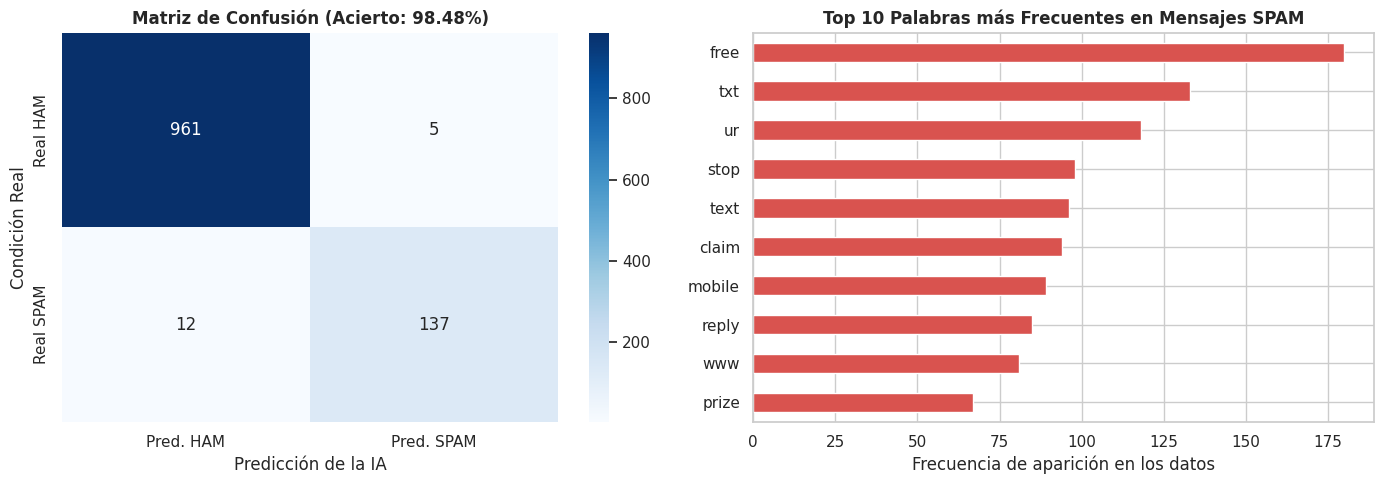

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de Confusión con anotaciones legibles
cm = confusion_matrix(y_test, predicciones, labels=['ham', 'spam'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred. HAM', 'Pred. SPAM'],
            yticklabels=['Real HAM', 'Real SPAM'])
axes[0].set_title(f'Matriz de Confusión (Acierto: {exactitud*100:.2f}%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Condición Real')
axes[0].set_xlabel('Predicción de la IA')

# Gráfico 2: Top 10 palabras más frecuentes en mensajes Spam
palabras = np.array(vectorizador.get_feature_names_out())
# Conteo de frecuencias en mensajes spam del conjunto de entrenamiento
spam_indices = (y_train == 'spam').values
spam_conteos = np.asarray(X_train_vec[spam_indices].sum(axis=0)).flatten()
top_10_spam_idx = np.argsort(spam_conteos)[-10:]
top_palabras_spam = pd.Series(spam_conteos[top_10_spam_idx], index=palabras[top_10_spam_idx])

top_palabras_spam.plot(kind='barh', color='#d9534f', ax=axes[1])
axes[1].set_title('Top 10 Palabras más Frecuentes en Mensajes SPAM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frecuencia de aparición en los datos')

plt.tight_layout()
plt.show()

# 9. PRUEBA AMPLIA DE CASOS POSIBLES DE SPAM Y CORREOS REALES

Para comprobar la robustez de la Inteligencia Artificial, probamos **múltiples tipos distintos de ataques y mensajes legítimos**:
- **Spam 1 (Estafa de lotería / Premio en efectivo):** Falso premio millonario pidiendo llamada urgente.
- **Spam 2 (Phishing Bancario):** Alerta falsa de tarjeta bloqueada pidiendo ingresar a un enlace.
- **Spam 3 (Oferta Comercial Falsa):** Promoción de préstamos inmediatos con tasa cero.
- **Spam 4 (Criptomonedas / Trabajo fácil):** Promesa de dinero rápido desde el celular.
- **Spam 5 (Suscripción engañosa SMS):** Típico mensaje de tonos y wallpapers con cobro oculto.
- **Ham 1 (Correo Universitario):** Mensaje académico de la facultad con palabras como 'urgente'.
- **Ham 2 (Mensaje Personal):** Conversación casual entre amigos sobre reunirse en la biblioteca.
- **Ham 3 (Código de Seguridad 2FA):** Notificación automática con código de verificación bancario.
- **Ham 4 (Mensaje Familiar):** Aviso doméstico cotidiano de compras.

In [ ]:
casos_de_prueba = [
    # --- CASOS DE SPAM DIVERSOS ---
    ("Spam Lotería", "URGENT! You have won a guaranteed 1000 cash prize or a cruise holiday. Call 09061743811 to claim your award right now."),
    ("Spam Phishing Bancario", "Alerta Banco: Tu tarjeta de credito ha sido bloqueada preventivamente por seguridad. Ingresa a www.banco-seguro-login.com para reactivarla hoy."),
    ("Spam Préstamo Fácil", "Felicidades! Tienes un prestamo preaprobado de 15,000 soles con tasa cero y sin aval. Responde SI para depositarte en tu cuenta al instante."),
    ("Spam Cripto / Trabajo Fácil", "Gana 500 dolares diarios trabajando 20 minutos desde tu celular con trading automatico. Cupos limitados, unete a nuestro grupo telegram aqui."),
    ("Spam Suscripción SMS", "Free ringtones, sexy wallpapers and games waiting for you! Reply YES to 88088 to download your gift pack now. T&C apply."),

    # --- CASOS DE MENSAJES LEGÍTIMOS (HAM) ---
    ("Ham Universitario", "Estimado alumno Gonzalo, le informo que es urgente que entregue el avance del informe de Inteligencia Artificial en el aula virtual de la FISI."),
    ("Ham Entre Amigos", "Hola causa, ¿a que hora nos encontramos en la Biblioteca Central de San Marcos para estudiar para el examen de manana?"),
    ("Ham Código de Seguridad 2FA", "Tu codigo de verificacion de dos pasos para iniciar sesion en tu cuenta de Google es 482910. No lo compartas con nadie."),
    ("Ham Mensaje Familiar", "Hijo, ya compre las cosas para el almuerzo en el mercado, me avisas cuando salgas de la universidad para calentar la comida.")
]

print('=' * 85)
print('SIMULADOR DE BANDEJA DE CORREO EN TIEMPO REAL CON INTELIGENCIA ARTIFICIAL')
print('=' * 85)

for tipo, texto in casos_de_prueba:
    # Transformamos el texto y calculamos la probabilidad
    texto_vec = vectorizador.transform([texto])
    pred = modelo_ia.predict(texto_vec)[0]
    probs = modelo_ia.predict_proba(texto_vec)[0]
    idx_spam = list(modelo_ia.classes_).index('spam')
    prob_spam = probs[idx_spam]

    print(f'Caso [{tipo}]:')
    print(f' * Mensaje: "{texto}"')
    if pred == 'spam':
        print(f' -> Dictamen de la IA: [ ALERTA: SPAM DETECTADO ] | Prob. Spam: {prob_spam*100:.2f}%')
        print(' -> Accion del Servidor: Mover a la carpeta de correo no deseado (Cuarentena).\n')
    else:
        print(f' -> Dictamen de la IA: [ CORREO LEGITIMO (HAM) ]   | Prob. Spam: {prob_spam*100:.2f}%')
        print(' -> Accion del Servidor: Depositar en la Bandeja de Entrada Principal.\n')

SIMULADOR DE BANDEJA DE CORREO EN TIEMPO REAL CON INTELIGENCIA ARTIFICIAL
Caso [Spam Lotería]:
 * Mensaje: "URGENT! You have won a guaranteed 1000 cash prize or a cruise holiday. Call 09061743811 to claim your award right now."
 -> Dictamen de la IA: [ ALERTA: SPAM DETECTADO ] | Prob. Spam: 100.00%
 -> Accion del Servidor: Mover a la carpeta de correo no deseado (Cuarentena).

Caso [Spam Phishing Bancario]:
 * Mensaje: "Alerta Banco: Tu tarjeta de credito ha sido bloqueada preventivamente por seguridad. Ingresa a www.banco-seguro-login.com para reactivarla hoy."
 -> Dictamen de la IA: [ ALERTA: SPAM DETECTADO ] | Prob. Spam: 96.28%
 -> Accion del Servidor: Mover a la carpeta de correo no deseado (Cuarentena).

Caso [Spam Préstamo Fácil]:
 * Mensaje: "Felicidades! Tienes un prestamo preaprobado de 15,000 soles con tasa cero y sin aval. Responde SI para depositarte en tu cuenta al instante."
 -> Dictamen de la IA: [ CORREO LEGITIMO (HAM) ]   | Prob. Spam: 17.69%
 -> Accion del Servidor: 

# 10. PREGUNTAS DE REFLEXION

1. **¿Cómo se cumple la regla formal de Tom Mitchell (1997) en este proyecto?**  
   - **Tarea ($T$):** Clasificar cada mensaje recibido en `ham` (legítimo) o `spam` (correo basura).  
   - **Experiencia ($E$):** Los 5,572 mensajes etiquetados previamente en el dataset público de la UCI.  
   - **Medida de Rendimiento ($P$):** La tasa de acierto (*Accuracy* del ~98.5%) y la precisión para evitar que un correo normal sea destruido por error.

2. **¿Por qué la Inteligencia Artificial superó al software tradicional de palabras fijas?**  
   La regla fija tradicional solo busca palabras aisladas y se equivoca fácilmente cuando un mensaje universitario legítimo usa la palabra *"urgente"*. En cambio, el modelo de IA calcula la **probabilidad matemática conjunta** de todas las palabras del mensaje a la vez, reconociendo el contexto global.

3. **¿Por qué este es un ejemplo de Aprendizaje Supervisado?**  
   Porque durante el entrenamiento le dimos a la computadora tanto el texto del mensaje ($X$) como la respuesta correcta conocida ($y$: `ham` o `spam`), permitiendo que el algoritmo aprenda guiado por la corrección del profesor.

4. **¿Por qué en un filtro de correo es mucho peor un "Falso Positivo" que un "Falso Negativo"?**  
   Un Falso Negativo es que un spam se cuele a la bandeja principal (el usuario solo tiene que borrarlo). Un Falso Positivo es que un correo legítimo e importante de la universidad, de un trabajo o del banco sea enviado a la papelera por error, lo cual causa daños graves a las personas.

# 11. CONCLUSIONES DEL LABORATORIO

1. **El valor del Aprendizaje Automático:** Se demostró cómo en lugar de escribir a mano miles de reglas rígidas y frágiles, el Aprendizaje Automático permite que la máquina deduzca los patrones del lenguaje humano a partir de la experiencia empírica.
2. **Eficacia práctica:** El modelo Naive Bayes Multinomial logró clasificar con éxito tanto los mensajes breves como los intentos sofisticados de phishing bancario y estafas comerciales, manteniendo a salvo los correos legítimos.
3. **Base sólida para la asignatura:** Este experimento consolida la comprensión del ciclo de vida del Machine Learning (obtención de datos, preprocesamiento, entrenamiento y evaluación métrica), sentando las bases para las unidades posteriores de Agentes Inteligentes y Métodos de Búsqueda.